In [1]:
from ml_enhance import load_hpc_result, compare
from ml_enhance import CorrelationFilter
from ml_enhance import FeatureImportance
from sklearn.base import BaseEstimator
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np

In [124]:
KRR_combo_filtered_df = load_hpc_result(Path("../data/KRR_results/2_KRR_combo_filtered_results.pkl"), "KRR_topo+QM_filtered")
KRR_combo_filtered_df = KRR_combo_filtered_df[KRR_combo_filtered_df["test_r2"] > 0]

In [126]:
KRR_topo_filtered_df = load_hpc_result(Path("../data/KRR_results/2_KRR_topo_filtered_results.pkl"), "KRR_topo")
KRR_topo_filtered_df = KRR_topo_filtered_df[KRR_topo_filtered_df["test_r2"] > 0]

In [168]:
tst1 = KRR_combo_filtered_df.groupby("size")["test_r2"].agg(["mean", "std"])

In [169]:
tst2 = KRR_topo_filtered_df.groupby("size")["test_r2"].agg(["mean", "std"])

In [176]:
tst1 = tst1.rename(columns={"mean": "combo_mean", "std": "combo_std"})
tst2 = tst2.rename(columns={"mean": "topo_mean", "std": "topo_std"})

combined_df = pd.concat([tst1, tst2], axis=1)
combined_df["diff"] = combined_df["combo_mean"] - combined_df["topo_mean"]
combined_df = combined_df.sort_values("diff")
combined_df

,combo_mean,combo_std,topo_mean,topo_std,diff
size,,,,,
0.25,0.822471,0.010408,0.821599,0.010107,0.000872
0.50,0.845760,0.010255,0.842313,0.009569,0.003447
1.00,0.866426,0.008988,0.861859,0.008829,0.004567
0.10,0.789265,0.012541,0.780715,0.015078,0.008550


In [177]:
combined_df["num_samples"] = 8763 * combined_df.index
combined_df

,combo_mean,combo_std,topo_mean,topo_std,diff,num_samples
size,,,,,,
0.25,0.822471,0.010408,0.821599,0.010107,0.000872,2190.75
0.50,0.845760,0.010255,0.842313,0.009569,0.003447,4381.50
1.00,0.866426,0.008988,0.861859,0.008829,0.004567,8763.00
0.10,0.789265,0.012541,0.780715,0.015078,0.008550,876.30


In [178]:
plt.figure(figsize=(8, 5))


# draw lines (the "dumbbell sticks")
for row in combined_df.itertuples():
    plt.plot(
        [row.num_samples, row.num_samples],
        [row.topo, row.combo],
        color="gray",
        linewidth=2,
        zorder=1
    )

# # draw endpoints
plt.scatter(combined_df["num_samples"], combined_df["topo"], color="black", label="Topo", zorder=2)
plt.scatter(combined_df["num_samples"], combined_df["combo"], color="tab:blue", label="Topo+QM", zorder=3)



# for i, row in enumerate(df_mean.itertuples()):
#     plt.text(row.Topo, i, f"{row.Topo:.2f}", va="bottom", ha="right")
#     plt.text(row._3, i, f"{row._3:.2f}", va="bottom", ha="left")

# # labels
# plt.yticks(y_pos, df_mean["group"])
# plt.xlabel(r"$R^2$ score")
# plt.title("Model performance: Topo vs Topo+QM")

# plt.legend(frameon=False)
# plt.grid(axis="x", linestyle="--", alpha=0.4)

# plt.xscale("log")

plt.tight_layout()
plt.show()

AttributeError: 'Pandas' object has no attribute 'topo'

<Figure size 800x500 with 0 Axes>

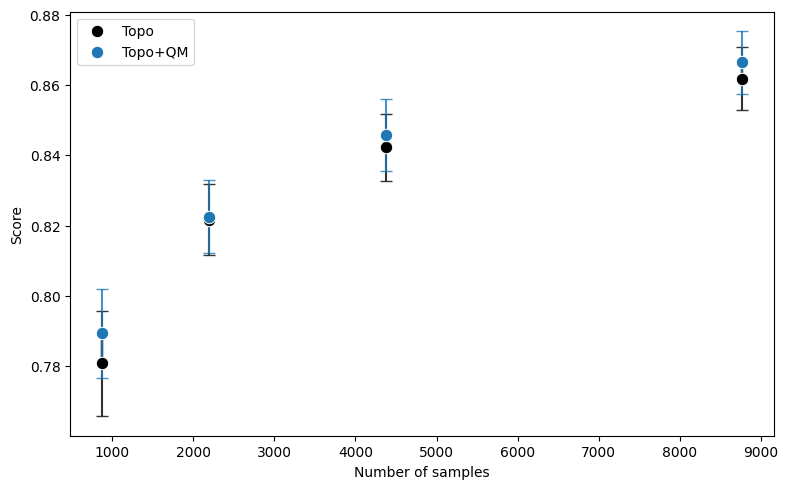

In [180]:
plt.figure(figsize=(8, 5))

# dumbbell lines
for row in combined_df.itertuples():
    plt.plot(
        [row.num_samples, row.num_samples],
        [row.topo_mean, row.combo_mean],
        color="lightgray",
        linewidth=3,
        zorder=1
    )

# scatter points (use seaborn)
sns.scatterplot(
    data=combined_df,
    x="num_samples",
    y="topo_mean",
    color="black",
    s=80,
    label="Topo",
    zorder=3
)

sns.scatterplot(
    data=combined_df,
    x="num_samples",
    y="combo_mean",
    color="tab:blue",
    s=80,
    label="Topo+QM",
    zorder=4
)

# error bars
plt.errorbar(
    combined_df["num_samples"],
    combined_df["topo_mean"],
    yerr=combined_df["topo_std"],
    fmt="none",
    ecolor="black",
    capsize=4,
    alpha=0.8,
    zorder=2
)

plt.errorbar(
    combined_df["num_samples"],
    combined_df["combo_mean"],
    yerr=combined_df["combo_std"],
    fmt="none",
    ecolor="tab:blue",
    capsize=4,
    alpha=0.8,
    zorder=2
)

plt.xlabel("Number of samples")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()

In [111]:
size = 0.1

fold_id
0          0.782510
1         -3.796969
2          0.789929
3          0.800798
4          0.780034
5          0.796317
6          0.786411
7          0.826638
8          0.791126
9          0.767310
10         0.784336
11         0.803974
12        -0.010659
13         0.782804
14         0.780124
15         0.792718
16   -519771.965661
17         0.798509
18         0.790102
19         0.766996
20         0.791301
21         0.788986
22         0.782621
23         0.796800
24         0.783479
Name: test_r2, dtype: float64


(0.0, 1.0)

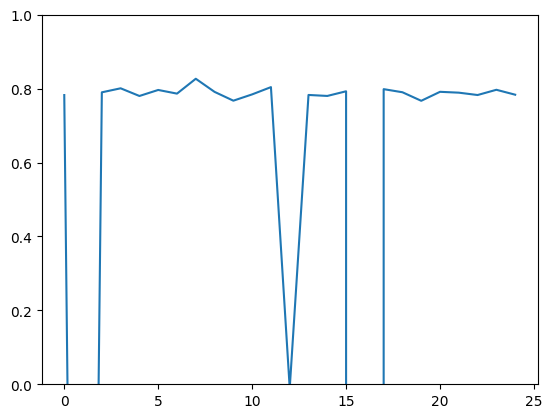

In [112]:
KRR_01_df = KRR_combo_filtered_df[KRR_combo_filtered_df["size"] == size].sort_index()
print(KRR_01_df["test_r2"])
plt.plot(KRR_01_df.index, KRR_01_df["test_r2"])
plt.ylim(0, 1)

fold_id
0     0.762742
1    -4.109465
2     0.783975
3     0.793396
4     0.778862
5     0.796242
6     0.773416
7     0.821127
8     0.786063
9     0.751644
10    0.771047
11    0.802033
12   -2.266474
13    0.775616
14    0.769182
15    0.790398
16    0.775996
17    0.795063
18    0.784993
19    0.759505
20    0.774473
21    0.775322
22    0.782265
23    0.783623
24    0.769462
Name: test_r2, dtype: float64


(0.0, 1.0)

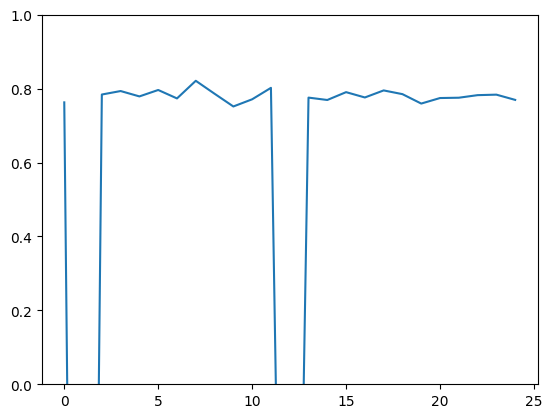

In [106]:
KRR_01_df = KRR_topo_filtered_df[KRR_topo_filtered_df["size"] == 0.1].sort_index()
print(KRR_01_df["test_r2"])
plt.plot(KRR_01_df.index, KRR_01_df["test_r2"])
plt.ylim(0, 1)

In [113]:
pos_folds = KRR_01_df[KRR_01_df["test_r2"] > 0].index.to_list()

In [114]:
file = Path(r"..\data\KRR_results\2_KRR_combo_filtered_PFI_results.csv")
krr_combo_fi_df = pd.read_csv(file)
grouped = krr_combo_fi_df[krr_combo_fi_df["fold_id"].isin(pos_folds)].groupby("size")
data = grouped.get_group(size)
groups = data[["fold_id", "feature", "r2_mean"]]
FI_dict = {
    fold_id: df.set_index("feature")["r2_mean"]
    for fold_id, df in groups.groupby("fold_id")
}

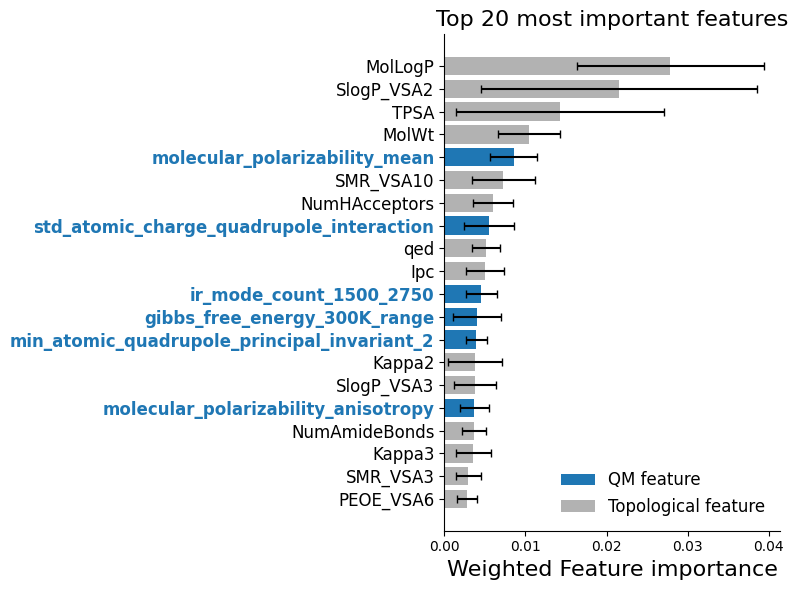

In [115]:
FI = FeatureImportance(KRR_01_df[KRR_01_df["test_r2"] > 0], provided_FI=FI_dict)
fi_df = FI.get_feature_importance(20)
FI.plot(20)